In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

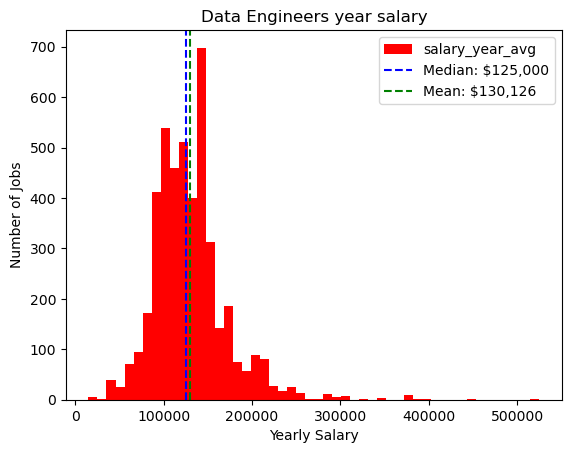

In [20]:
df_DE = df[df['job_title_short'] == 'Data Engineer']
df_DE = df_DE.dropna(subset= 'salary_year_avg')


median_salary = df_DE['salary_year_avg'].median()
mean_salary = df_DE['salary_year_avg'].mean()


df_DE['salary_year_avg'].plot(kind = 'hist', bins = 50, color = 'red')

plt.axvline(median_salary, color= 'blue', linestyle= '--', label= f'Median: ${median_salary:,.0f}')
plt.axvline(mean_salary, color= 'green', linestyle= '--', label= f'Mean: ${mean_salary:,.0f}')

plt.title('Data Engineers year salary')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.legend()